<a href="https://colab.research.google.com/github/akash-g0807/Numerical-Analysis/blob/main/2_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

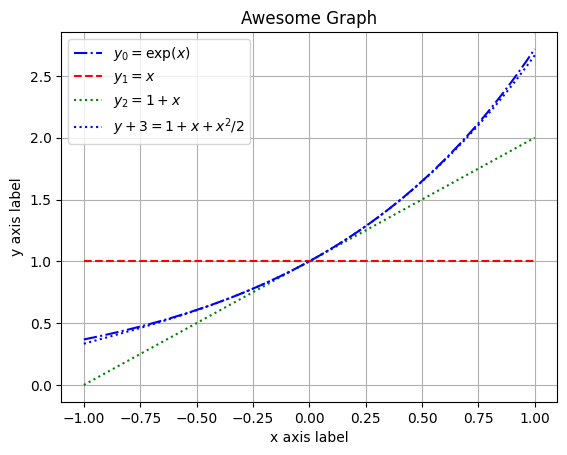

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = np.linspace(-1,1,100)
y0 = np.exp(x)
y1 = np.ones_like(x)
y2 = 1+x
y3 = 1 + x + np.power(x,2)/2
y4 = 1 + x + np.power(x,2)/2 + np.power(x,3)/6

# (notice that they will be on the same axes)
plt.plot(x, y0, 'b-.', label=r"$y_0 = \exp(x)$")
plt.plot(x, y1, 'r--', label=r"$y_1 = x$")
plt.plot(x, y2, 'g:', label=r"$y_2 = 1+x$")
plt.plot(x, y4, 'b:', label=r"$y+3 = 1+x+x^2/2$")

# put in a grid, legend, title, and axis labels
plt.grid()
plt.legend()
plt.title("Awesome Graph")
plt.xlabel('x axis label')
plt.ylabel('y axis label')
plt.show()


In [ ]:
def exp_approx(x, n):
    if n < 0:
        raise ValueError("n must be at least 0")
    # Start with zero-order approximation
    approximation = 1.0
    # Add higher-order terms
    for i in range(1, n + 1):
        approximation += x**i/math.factorial(i)
    return approximation

def exp_approx2(x, n):
    if n < 0:
        raise ValueError("n must be at least 0")

    term = 1.0        # x^0 / 0!
    total = term      # start with first term

    for i in range(1, n + 1):
        term *= x     # one multiplication
        term /= i     # one division
        total += term # one addition

    return total


# Approximating exponential function at -1: e^-1
print(np.exp(-1))
print(exp_approx(-1, 3))


0.36787944117144233
0.33333333333333337


0.002999995500002025


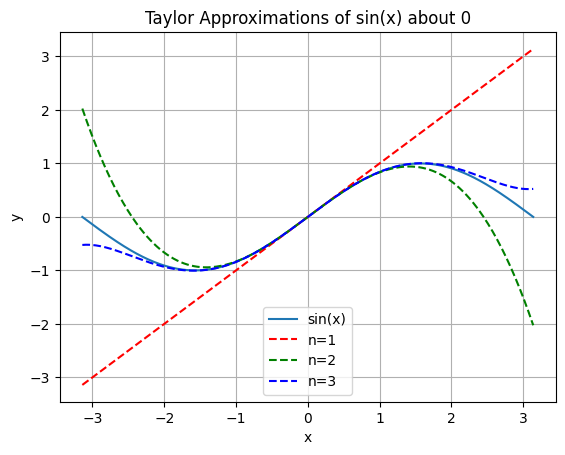

In [ ]:
def sin_approx(x,n):
  if n < 0:
    raise ValueError("n must be at least 0")

  approximation = 0.0

  for k in range (1, n + 2, 2):
    sign = -1 if ((k - 1) // 2) %  2 == 1 else 1
    approximation += sign * (x**k) / math.factorial(k)

  return approximation

def sin_approx2(x,n):
  if n < 0:
    raise ValueError("n must be at least 0")

  if n < 1:
        return 0.0  # no x term allowed
  term = x          # first term: x
  approximation = term

  k = 0  # corresponds to term with power (2k+1)

  while True:
      next_power = 2*(k+1) + 1
      if next_power > n:
          break

      term *= -x*x / ((2*k+2)*(2*k+3))
      approximation += term
      k += 1

  return approximation

print(sin_approx(0.003,5))

# Making a plot
x = np.linspace(-np.pi, np.pi, 400)

y_true = np.sin(x)
y1 = np.array([sin_approx(val, 1) for val in x])
y3 = np.array([sin_approx(val, 3) for val in x])
y5 = np.array([sin_approx(val, 5) for val in x])

plt.plot(x, y_true, label="sin(x)")
plt.plot(x, y1, "r--", label="n=1")
plt.plot(x, y3, "g--", label="n=2")
plt.plot(x, y5, "b--", label="n=3")

plt.grid(True)
plt.legend()
plt.title("Taylor Approximations of sin(x) about 0")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


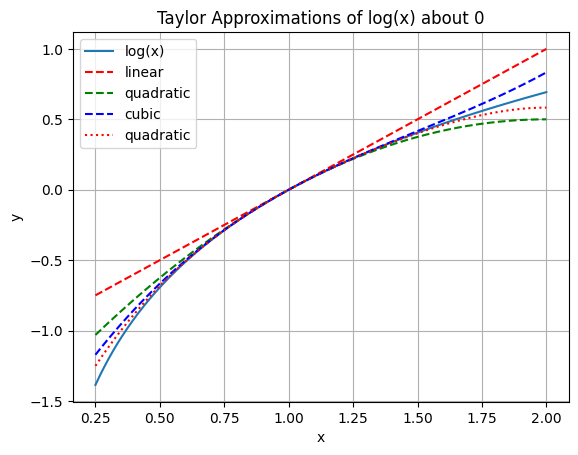

0.09533333333333342

In [ ]:
def log_approx(x, n):
    if x <= 0:
        raise ValueError("log(x) is only defined for x > 0")

    approximation = 0.0
    h = x - 1

    for k in range(1, n + 1):
        sign = (-1)**(k + 1)
        approximation += sign * (h**k) / k

    return approximation

def log_approx2(x, n):
    if x <= 0:
        raise ValueError("log(x) is only defined for x > 0")

    h = x - 1
    term = h
    approximation = term

    for k in range(2, n + 1):
        term *= -h * (k - 1) / k
        approximation += term

    return approximation

# Making a plot
x = np.linspace(0.25, 2, 400)

y_true = np.log(x)
y1 = np.array([log_approx2(val, 1) for val in x])
y2 = np.array([log_approx2(val, 2) for val in x])
y3 = np.array([log_approx2(val, 3) for val in x])
y4 = np.array([log_approx2(val, 4) for val in x])

plt.plot(x, y_true, label="log(x)")
plt.plot(x, y1, "r--", label="linear")
plt.plot(x, y2, "g--", label="quadratic")
plt.plot(x, y3, "b--", label="cubic")
plt.plot(x, y4, "r:", label="quadratic")

plt.grid(True)
plt.legend()
plt.title("Taylor Approximations of log(x) about 0")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

log_approx2(1.1,3)

In [ ]:
print(f"{'Order n':<20} | {'f_n(0.1)':<20} | {'ε_n(0.1)':<20} | {'f_n(0.2)':<20} | {'ε_n(0.2)':<20} | {'ε_n(0.2)/ε_n(0.1)':<20}")
print("-" * 140)

order = 5

for i in range(0, order + 1):
    e_1 = exp_approx2(0.1, i)
    e_2 = exp_approx2(0.2, i)

    err_1 = abs(np.exp(0.1) - e_1)
    err_2 = abs(np.exp(0.2) - e_2)
    ratio = err_2/err_1

    print(f"{i:<20} | {e_1:<20.10f} | {err_1:<20.10f} | {e_2:<20.10f} | {err_2:<20.10f} | {ratio:<20.9f}")

Order n              | f_n(0.1)             | ε_n(0.1)             | f_n(0.2)             | ε_n(0.2)             | ε_n(0.2)/ε_n(0.1)   
--------------------------------------------------------------------------------------------------------------------------------------------
0                    | 1.0000000000         | 0.1051709181         | 1.0000000000         | 0.2214027582         | 2.105170918         
1                    | 1.1000000000         | 0.0051709181         | 1.2000000000         | 0.0214027582         | 4.139063479         
2                    | 1.1050000000         | 0.0001709181         | 1.2200000000         | 0.0014027582         | 8.207196078         
3                    | 1.1051666667         | 0.0000042514         | 1.2213333333         | 0.0000694248         | 16.329839624        
4                    | 1.1051708333         | 0.0000000847         | 1.2214000000         | 0.0000027582         | 32.547614331        
5                    | 1.1051709167        

In [ ]:
print(f"{'Order n':<20} | {'f_n(0.1)':<20} | {'ε_n(0.1)':<20} | {'f_n(0.2)':<20} | {'ε_n(0.2)':<20} | {'ε_n(0.2)/ε_n(0.1)':<20}")
print("-" * 140)

order = 7

for i in range(1, order + 1, 2):
    e_1 = sin_approx2(0.1, i)
    e_2 = sin_approx2(0.2, i)

    err_1 = abs(np.sin(0.1) - e_1)
    err_2 = abs(np.sin(0.2) - e_2)
    ratio = err_2/err_1

    print(f"{i:<20} | {e_1:<20.13f} | {err_1:<20.13f} | {e_2:<20.13f} | {err_2:<20.13f} | {ratio:<20.9f}")

Order n              | f_n(0.1)             | ε_n(0.1)             | f_n(0.2)             | ε_n(0.2)             | ε_n(0.2)/ε_n(0.1)   
--------------------------------------------------------------------------------------------------------------------------------------------
1                    | 0.1000000000000      | 0.0001665833532      | 0.2000000000000      | 0.0013306692049      | 7.988008283         
3                    | 0.0998333333333      | 0.0000000833135      | 0.1986666666667      | 0.0000026641284      | 31.977153288        
5                    | 0.0998334166667      | 0.0000000000198      | 0.1986693333333      | 0.0000000025383      | 127.946650475       
7                    | 0.0998334166468      | 0.0000000000000      | 0.1986693307937      | 0.0000000000014      | 513.282828283       


In [ ]:
print(f"{'Order n':<10} | {'f_n(1.1)':<20} | {'ε_n(1.1)':<20} | {'f_n(1.02)':<20} | {'ε_n(1.02)':<20} | {'ε_n(1.1)/ε_n(1.02)':<20}")
print("-" * 130)

order = 5

for i in range(1, order + 1):
    approx_1 = log_approx2(1.1, i)
    approx_2 = log_approx2(1.02, i)

    err_1 = abs(np.log(1.1) - approx_1)
    err_2 = abs(np.log(1.02) - approx_2)

    ratio = err_1 / err_2 if err_2 != 0 else float("inf")

    print(f"{i:<10} | {approx_1:<20.13f} | {err_1:<20.13e} | {approx_2:<20.13f} | {err_2:<20.13e} | {ratio:<20.9f}")


Order n    | f_n(1.1)             | ε_n(1.1)             | f_n(1.02)            | ε_n(1.02)            | ε_n(1.1)/ε_n(1.02)  
----------------------------------------------------------------------------------------------------------------------------------
1          | 0.1000000000000      | 4.6898201956752e-03  | 0.0200000000000      | 1.9737270382029e-04  | 23.761240054        
2          | 0.0950000000000      | 3.1017980432485e-04  | 0.0198000000000      | 2.6272961797108e-06  | 118.060463346       
3          | 0.0953333333333      | 2.3153529008488e-05  | 0.0198026666667      | 3.9370486957374e-08  | 588.093539040       
4          | 0.0953083333333      | 1.8464709915095e-06  | 0.0198026266667      | 6.2951304238834e-10  | 2933.173528072      
5          | 0.0953103333333      | 1.5352900849253e-07  | 0.0198026273067      | 1.0486958523792e-11  | 14639.993868976     


In [ ]:
exp_approx(0.5,4)

1.6484375

In [ ]:
log_approx(1.1,5)

0.09531033333333343